# Question 1 — Convolution

### Manual Convolution Implementation

In [14]:
import numpy as np

def manual_convolve2d(image, kernel, padding='same', strides=1):
    """
    To have different padding pass an int with the padding you want
    Default padding (same) keeps the image shape
    """
    k_h, k_w = kernel.shape
    h, w = image.shape

    if padding == 'same':
        pad_h = (k_h - 1) // 2
        pad_w = (k_w - 1) // 2
    else:
        pad_h = padding
        pad_w = padding

    padded_h = h + (2 * pad_h)
    padded_w = w + (2 * pad_w)
    padded_image = np.zeros((padded_h, padded_w))

    padded_image[pad_h : pad_h + h, pad_w : pad_w + w] = image

    out_h = (padded_h - k_h) // strides + 1
    out_w = (padded_w - k_w) // strides + 1

    output = np.zeros((out_h, out_w))

    for y in range(out_h):
        for x in range(out_w):
            start_y = y * strides
            end_y = start_y + k_h
            start_x = x * strides
            end_x = start_x + k_w

            roi = padded_image[start_y:end_y, start_x:end_x]
            k = (roi * kernel).sum()

            output[y, x] = k

    return output

input_image = np.array([
    [10, 10, 10, 0, 0],
    [10, 10, 10, 0, 0],
    [10, 10, 10, 0, 0],
    [0,  0,  0, 0, 0],
    [0,  0,  0, 0, 0]
])

kernel_odd = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

kernel_even = np.ones((2, 2)) * 0.25

result_odd = manual_convolve2d(input_image, kernel_odd, padding=1)
print(result_odd)

result_even = manual_convolve2d(input_image, kernel_even, padding=0)
print(result_even)

[[ 30.   0. -30. -30.   0.]
 [ 40.   0. -40. -40.   0.]
 [ 30.   0. -30. -30.   0.]
 [ 10.   0. -10. -10.   0.]
 [  0.   0.   0.   0.   0.]]
[[10.  10.   5.   0. ]
 [10.  10.   5.   0. ]
 [ 5.   5.   2.5  0. ]
 [ 0.   0.   0.   0. ]]


### Test Your Convolution Function

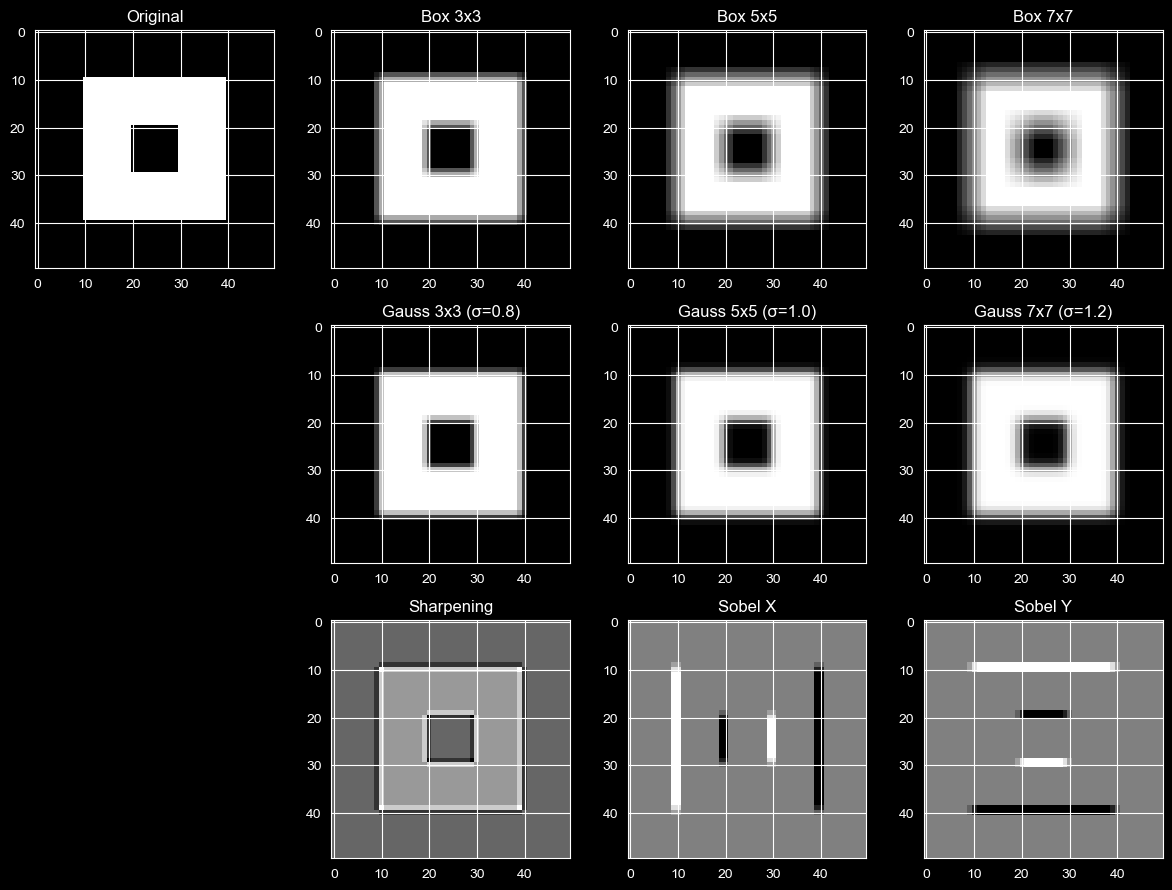

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def get_box_kernel(size):
    return np.ones((size, size)) / (size * size)

def get_gaussian_kernel(size, sigma):

    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / np.sum(kernel)

sharpen_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])


image = np.zeros((50, 50))
image[10:40, 10:40] = 1.0
image[20:30, 20:30] = 0.0

box_sizes = [3, 5, 7]
box_results = [manual_convolve2d(image, get_box_kernel(s)) for s in box_sizes]

gauss_configs = [(3, 0.8), (5, 1.0), (7, 1.2)]
gauss_results = [manual_convolve2d(image, get_gaussian_kernel(s, sig)) for s, sig in gauss_configs]

sharpen_result = manual_convolve2d(image, sharpen_kernel)
sobel_x_result = manual_convolve2d(image, sobel_x)
sobel_y_result = manual_convolve2d(image, sobel_y)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
plt.tight_layout()

axes[0, 0].imshow(image, cmap='gray'); axes[0, 0].set_title("Original")
axes[0, 1].imshow(box_results[0], cmap='gray'); axes[0, 1].set_title("Box 3x3")
axes[0, 2].imshow(box_results[1], cmap='gray'); axes[0, 2].set_title("Box 5x5")
axes[0, 3].imshow(box_results[2], cmap='gray'); axes[0, 3].set_title("Box 7x7")

axes[1, 0].axis('off')
axes[1, 1].imshow(gauss_results[0], cmap='gray'); axes[1, 1].set_title("Gauss 3x3 (σ=0.8)")
axes[1, 2].imshow(gauss_results[1], cmap='gray'); axes[1, 2].set_title("Gauss 5x5 (σ=1.0)")
axes[1, 3].imshow(gauss_results[2], cmap='gray'); axes[1, 3].set_title("Gauss 7x7 (σ=1.2)")

axes[2, 0].axis('off')
axes[2, 1].imshow(sharpen_result, cmap='gray'); axes[2, 1].set_title("Sharpening")
axes[2, 2].imshow(sobel_x_result, cmap='gray'); axes[2, 2].set_title("Sobel X")
axes[2, 3].imshow(sobel_y_result, cmap='gray'); axes[2, 3].set_title("Sobel Y")

plt.show()

### Compare With OpenCV

Kernel Type               | MAE                  | MSE                 
---------------------------------------------------------------------------
Box Filter (5x5)          | 3.4304142001e-08     | 3.4494682665e-15    
Gaussian (5x5, s=1.0)     | 4.9173622033e-08     | 8.2299006680e-15    
Sobel X                   | 0.0000000000e+00     | 0.0000000000e+00    
Sharpening                | 0.0000000000e+00     | 0.0000000000e+00    


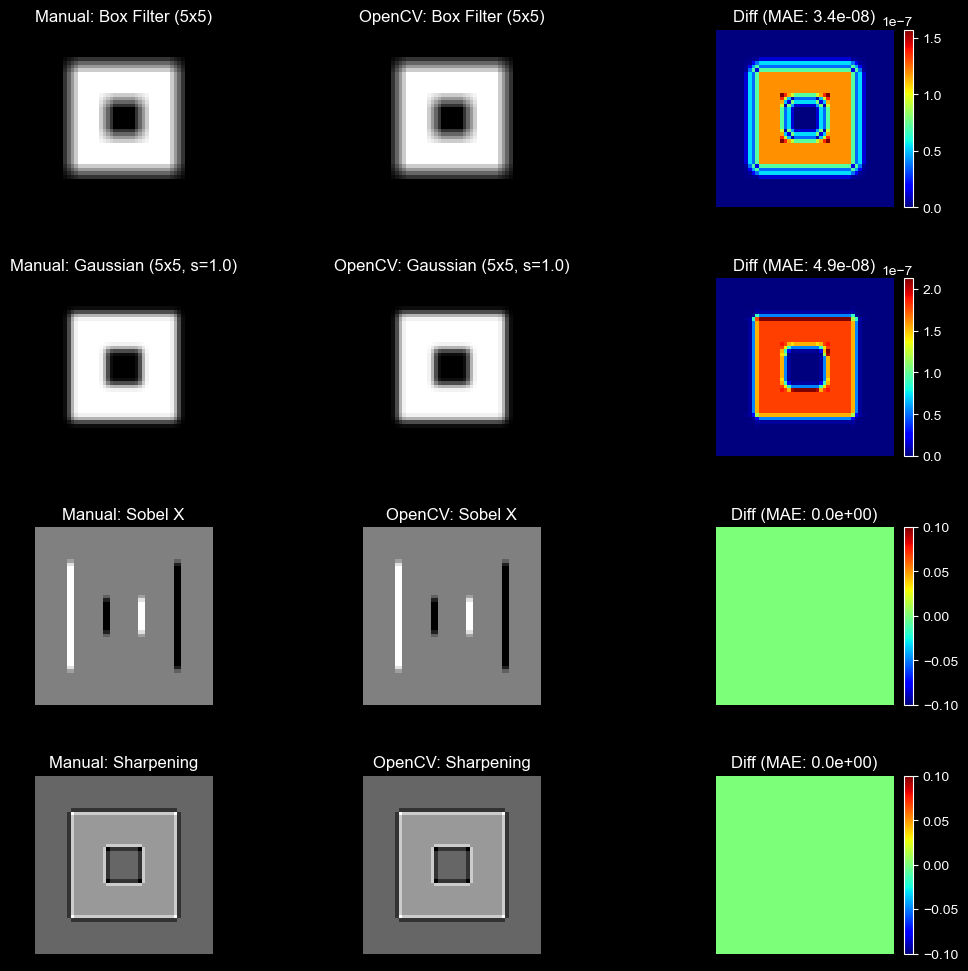

In [16]:
import cv2

image = np.zeros((50, 50), dtype=np.float32)
image[10:40, 10:40] = 1.0
image[20:30, 20:30] = 0.0

kernels = {
    "Box Filter (5x5)": get_box_kernel(5),
    "Gaussian (5x5, s=1.0)": get_gaussian_kernel(5, 1.0),
    "Sobel X": sobel_x,
    "Sharpening": sharpen_kernel
}

print(f"{'Kernel Type':<25} | {'MAE':<20} | {'MSE':<20}")
print("-" * 75)

fig, axes = plt.subplots(len(kernels), 3, figsize=(12, 12))
plt.subplots_adjust(hspace=0.4)

for i, (name, kernel) in enumerate(kernels.items()):

    manual_out = manual_convolve2d(image, kernel)

    cv2_out = cv2.filter2D(src=image, ddepth=-1, kernel=kernel, borderType=cv2.BORDER_CONSTANT)
    diff = np.abs(manual_out - cv2_out)
    mae = np.mean(diff)
    mse = np.mean(diff ** 2)

    print(f"{name:<25} | {mae:<20.10e} | {mse:<20.10e}")

    axes[i, 0].imshow(manual_out, cmap='gray')
    axes[i, 0].set_title(f"Manual: {name}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(cv2_out, cmap='gray')
    axes[i, 1].set_title(f"OpenCV: {name}")
    axes[i, 1].axis('off')

    im = axes[i, 2].imshow(diff, cmap='jet')
    axes[i, 2].set_title(f"Diff (MAE: {mae:.1e})")
    axes[i, 2].axis('off')
    plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.show()

### Compare Smoothing Behaviors

#### Which filter produces more excessive smoothing?

Box filter, since it treats the pixel value further away from the center of the kernel the way it does to close pixel and distant pixels are less likely to be part of the same object in the picture and could have very different pixel values in that case
That creates more blurry filter that loses the details of the original objects in the picture.

#### Why does Gaussian smoothing preserve edges better than simple averaging?

Edges are usually tight and gaussian filter gives more weight to close pixels compared to simple averaging.


#### Example
The boxes in the previous code block shows that the box filter gave a more blurry filter compared to the gaussian smoothing which perserved the edges better.

### Explain Differences Between Your Output and OpenCV

#### Numerical precision
Irrational values like e that appear in gaussian filter are probably not represented the same way between different libraries when looking long after the decimal point.


#### Border handling differences
From what I read in the internet it looks like cv2 uses reflect padding which mirrors the pixels in the edges to fill the gaps while my code uses zero padding which leaves them as black pixels with value 0.